# Character-Level RNN for Name Generation (Manual Implementation)
This notebook implements a character-level Recurrent Neural Network (RNN) from scratch (without PyTorch's built-in `nn.RNN`) to generate names from different languages.

In this model, we train a language model on a dataset of several thousand surnames from 18 languages of origin, and generate new names starting from a specific language and letter.

## 1. Data Preparation and Preprocessing
We start by loading files containing lists of names for each language, converting Unicode names to plain ASCII, and establishing a mapping of letters.


In [1]:
from io import open
import glob
import os
import unicodedata
import string

all_letters = string.ascii_letters + " .,;'-"
n_letters = len(all_letters) + 1 # Plus EOS marker

def findFiles(path):
   return glob.glob(path)

### Unicode to ASCII Conversion
Since the surnames come from many different countries, they contain various accents and diacritics. We define `unicodeToAscii` to normalize and convert these characters into plain English ASCII letters. We also define `readLines` to load names from a file and process them line by line.


In [2]:
# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

### Loading the Dataset
We build the `category_lines` dictionary, which maps each category (language) to its list of names. The list of all categories and the total number of categories are stored in `all_categories` and `n_categories` respectively.


In [3]:
# Build the category_lines dictionary, a list of lines per category
category_lines = {}
all_categories = []
for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

Let's print out the list of languages and verify that our Unicode-to-ASCII normalization is working correctly.


In [4]:
print('# categories:', n_categories, all_categories)
print(unicodeToAscii("O'Néàl"))

# categories: 18 ['Vietnamese', 'French', 'Portuguese', 'Russian', 'Polish', 'Dutch', 'Czech', 'Italian', 'Arabic', 'Scottish', 'Irish', 'German', 'Greek', 'English', 'Spanish', 'Korean', 'Chinese', 'Japanese']
O'Neal


## 2. Converting Data to Tensors
To feed the names into our neural network, we need to convert them into PyTorch Tensors.
- **Categories** are represented as one-hot vectors of size `<1 x n_categories>`.
- **Input Letters** are represented as one-hot matrices of size `<line_length x 1 x n_letters>`.
- **Target Letters** are represented as class index `LongTensor`s, shifted by one character, ending with the EOS (End of String) marker.


In [0]:
import torch

### Training Utilities
We define helper functions to randomly select a category and a name from that category to create a training pair.


In [0]:
import random

# Random item from a list
def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

# Get a random category and random line from that category
def randomTrainingPair():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    return category, line

### Tensor Creation Functions
Here we implement:
1. `categoryTensor`: One-hot vector for a category (language).
2. `inputTensor`: A 3D tensor of one-hot vectors for each letter in the input sequence.
3. `targetTensor`: A 1D tensor containing the indices of the next characters, plus the EOS token at the end.


In [0]:
# One-hot vector for category
def categoryTensor(category):
    li = all_categories.index(category)
    tensor = torch.zeros(1, n_categories)
    tensor[0][li] = 1
    return tensor

# One-hot matrix of first to last letters (not including EOS) for input
def inputTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li in range(len(line)):
        letter = line[li]
        tensor[li][0][all_letters.find(letter)] = 1
    return tensor

# LongTensor of second letter to end (EOS) for target
def targetTensor(line):
    letter_indexes = [all_letters.find(line[li]) for li in range(1, len(line))]
    letter_indexes.append(n_letters - 1) # EOS
    return torch.LongTensor(letter_indexes)

## 3. Creating the RNN Network Structure
We manually implement a Recurrent Neural Network (RNN) module.

Our manual RNN layer takes the **category vector**, the **current input letter**, and the **previous hidden state** as inputs. It combines them, passes them through linear layers to compute the new hidden state and the output, and applies dropout and log-softmax to predict the next letter.

$$\text{new\_hidden} = \text{i2h}(\text{category} \oplus \text{input} \oplus \text{hidden})$$
$$\text{output} = \text{i2o}(\text{category} \oplus \text{input} \oplus \text{hidden})$$
$$\text{output\_combined} = \text{hidden} \oplus \text{output}$$
$$\text{final\_output} = \text{Softmax}(\text{Dropout}(\text{o2o}(\text{output\_combined})))$$

where $\oplus$ represents tensor concatenation along the second dimension.


In [0]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        self.i2h = nn.Linear(n_categories + input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(n_categories + input_size + hidden_size, output_size)
        self.o2o = nn.Linear(hidden_size + output_size, output_size)
        self.dropout = nn.Dropout(0.1)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, category, input, hidden):
        #category = [1, n_categories]
        #input = [1, n_letters]
        #hidden = [1, hidden_size]

        input_combined = torch.cat((category, input, hidden), 1)

        #input_combined = [1, n_categories+ n_letters + hidden_size]

        hidden = self.i2h(input_combined)

        #hidden = [1, hidden_size]

        output = self.i2o(input_combined)

        #output = [1, output_size]

        output_combined = torch.cat((hidden, output), 1)

        #output_combined = [1, hidden_size + output_size]

        output = self.o2o(output_combined)

        #output = [1, output_size]

        output = self.dropout(output)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

We instantiate our custom RNN model with `n_letters` input size (representing the character vocabulary size), a hidden size of `512`, and `n_letters` output size.


In [0]:
model = RNN(n_letters, 512, n_letters)


### Parameter Count
Let's write a utility function to count the number of trainable parameters in our manual RNN network.


In [0]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 370,638 trainable parameters


## 4. Model Training
### Loss Function
Since the final layer of our RNN is a `LogSoftmax` layer, we use the Negative Log-Likelihood Loss (`NLLLoss`) as our objective function.


In [0]:
criterion = nn.NLLLoss()


### Device Configuration
We detect if a CUDA-capable GPU is available, otherwise default to CPU.


In [0]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


We move the model and loss function to the configured device.


In [0]:
model=model.to(device)
criterion=criterion.to(device)

We wrap our random training pair retrieval and convert them directly to tensors allocated on the correct device.


In [0]:
def randomTrainingExample():
    category, line = randomTrainingPair()
    category_tensor = categoryTensor(category)
    input_line_tensor = inputTensor(line)
    target_line_tensor = targetTensor(line)
    return category_tensor.to(device), input_line_tensor.to(device), target_line_tensor.to(device)

### Training Step Function
The `train` function performs a single forward and backward pass for a given training example.
- We initialize the hidden state to zero.
- We loop through each character in the input name, running the RNN forward pass step-by-step.
- We compute the cumulative loss against the shifted target characters.
- We run backpropagation (`loss.backward()`) and manually update the model parameters using basic Stochastic Gradient Descent (SGD) weight updates.


In [0]:

learning_rate = 0.0005

def train(category_tensor, input_line_tensor, target_line_tensor):
    target_line_tensor.unsqueeze_(-1)
    hidden = model.initHidden()
    hidden = hidden.to(device)

    model.zero_grad()

    loss = 0

    for i in range(input_line_tensor.size(0)):
        output, hidden = model(category_tensor, input_line_tensor[i], hidden)
        l = criterion(output, target_line_tensor[i])
        loss += l

    loss.backward()

    for p in model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item() / input_line_tensor.size(0)


### Training Helper
A quick helper function to track time elapsed during training.


In [0]:
import time
import math

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

### Main Training Loop
We train the model over 100,000 iterations, printing the running loss every 5,000 iterations and saving the average loss every 500 iterations for plotting.


In [0]:

n_iters = 100000
print_every = 5000
plot_every = 500
all_losses = []
total_loss = 0 # Reset every plot_every iters

start = time.time()

for iter in range(1, n_iters + 1):
    output, loss = train(*randomTrainingExample())
    total_loss += loss

    if iter % print_every == 0:
        print('%s (%d %d%%) %.4f' % (timeSince(start), iter, iter / n_iters * 100, loss))

    if iter % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0

0m 36s (5000 5%) 2.7790
1m 11s (10000 10%) 2.7435
1m 46s (15000 15%) 2.3354
2m 22s (20000 20%) 2.7419
2m 57s (25000 25%) 3.0291
3m 32s (30000 30%) 2.7915
4m 7s (35000 35%) 2.5828
4m 42s (40000 40%) 2.7244
5m 17s (45000 45%) 2.3808
5m 52s (50000 50%) 2.5245
6m 28s (55000 55%) 2.6907
7m 3s (60000 60%) 3.0445
7m 38s (65000 65%) 2.4734
8m 14s (70000 70%) 3.1509
8m 49s (75000 75%) 2.3023
9m 25s (80000 80%) 2.5233
10m 1s (85000 85%) 2.6283
10m 37s (90000 90%) 1.7882
11m 12s (95000 95%) 1.4711
11m 47s (100000 100%) 1.7843


### Plotting the Training Loss
We plot the historical loss values over time to visualize the training progress.


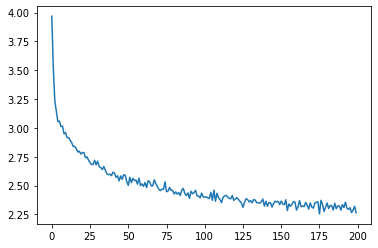

In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

## 5. Name Generation (Sampling)
To generate names, we feed the network a start letter and a category (language) and iteratively predict the next letter.
- In each step, we pass the current letter and hidden state to the model.
- We pick the highest probability letter as the next character.
- If the model predicts the EOS marker, we stop generating.
- Otherwise, we append the predicted letter to our output and repeat the process using the predicted letter as the next input.


In [0]:
max_length = 20

# Sample from a category and starting letter
def sample(category, start_letter='A'):
    with torch.no_grad():  # no need to track history in sampling
        category_tensor = categoryTensor(category)
        input = inputTensor(start_letter)
        hidden = model.initHidden()

        output_name = start_letter

        for i in range(max_length):
            output, hidden = model(category_tensor, input[0], hidden)
            topv, topi = output.topk(1)
            topi = topi[0][0]
            if topi == n_letters - 1:
                break
            else:
                letter = all_letters[topi]
                output_name += letter
            input = inputTensor(letter)

        return output_name

# Get multiple samples from one category and multiple starting letters
def samples(category, start_letters='ABC'):
    for start_letter in start_letters:
        print(sample(category, start_letter))

samples('Russian', 'RUS')

samples('German', 'GER')

samples('Spanish', 'SPA')

samples('Chinese', 'CHI')

Roskan
Uarichovove
Salovak
Gares
Ering
Rour
Salla
Pare
Allan
Chan
Han
Iun


Let's generate some French names starting with the letter 'T'.


In [0]:
samples('French', 'T')


Tare
